# HOMEWORK 9

In this homework, you are going to use the dlib face detector and apply it to an image of your liking. You can follow the procedure shown in lesson 9. Please always comment your code so I can see what you're doing :-)

For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

### Step 0

Run the necessary imports.

In [95]:
import cv2
import numpy as np
import dlib
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 1

Load an image (any image that contains faces).

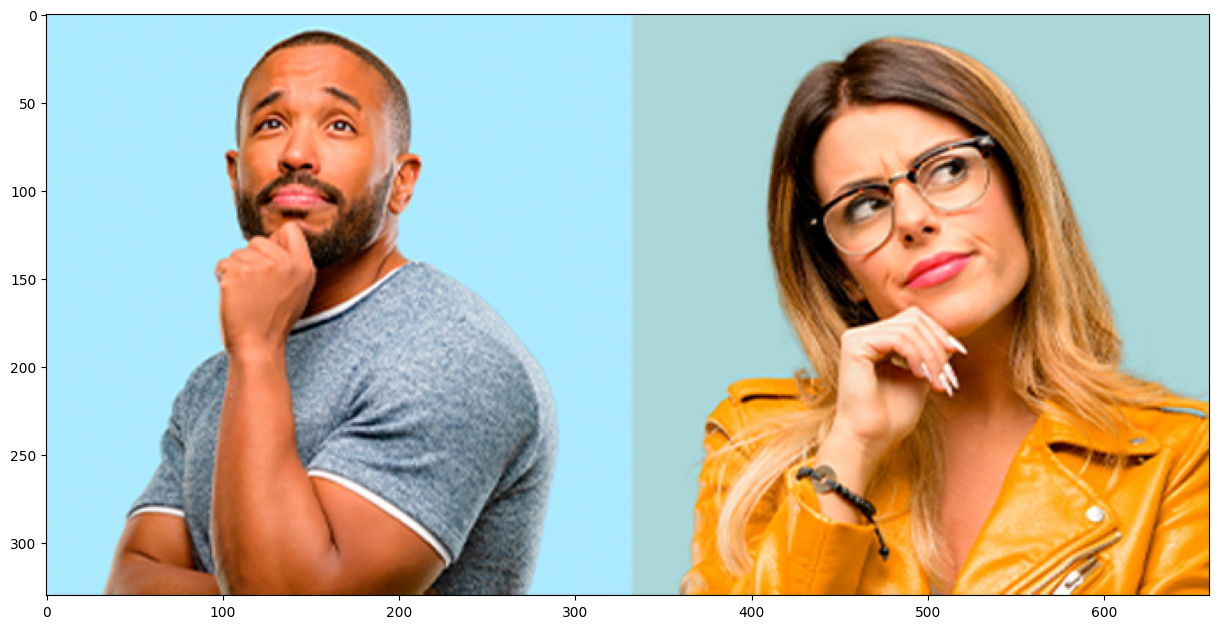

In [96]:
# Loading image. I use photo with a few face for better demonstration
img = cv2.imread("../data/couple.jpg")


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)

plt.figure()
plt.imshow(img_rgb)




### Step 2

Load the dlib face predictor.

In [97]:
# Initialization dlib
#
detector = dlib.get_frontal_face_detector()

print("The detector dlib saccefull loading!")


The detector dlib saccefull loading!


### Step 3

Run the predictor on your image.

In [98]:
# Applying the detector. Parameter 1 is the unsampling factor. Amount 1  like standart
rects = detector(gray, 1)


print(f'\nThe number of detected faces: {len(rects)}')

# Output the coordinates of each detected face
for i, rect in enumerate(rects):
    print(f"Face {i+1}: left={rect.left()}, top={rect.top()}, "
          f"right={rect.right()}, bottom={rect.bottom()}")


The number of detected faces: 2
Face 1: left=438, top=68, right=545, bottom=175
Face 2: left=106, top=36, right=195, bottom=126


### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

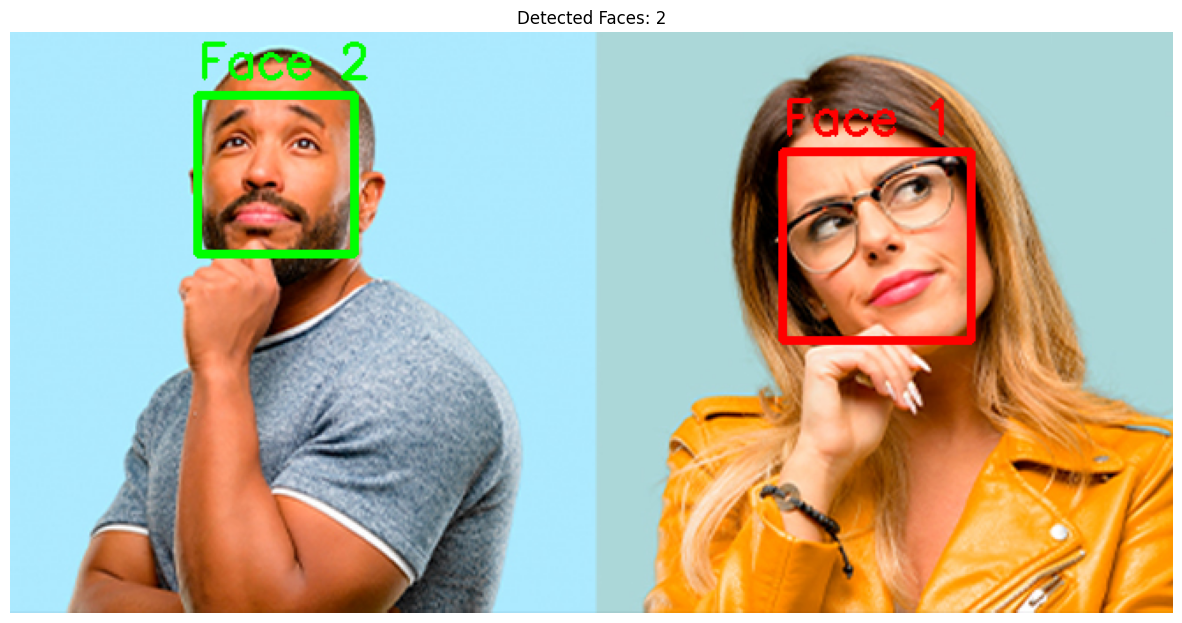

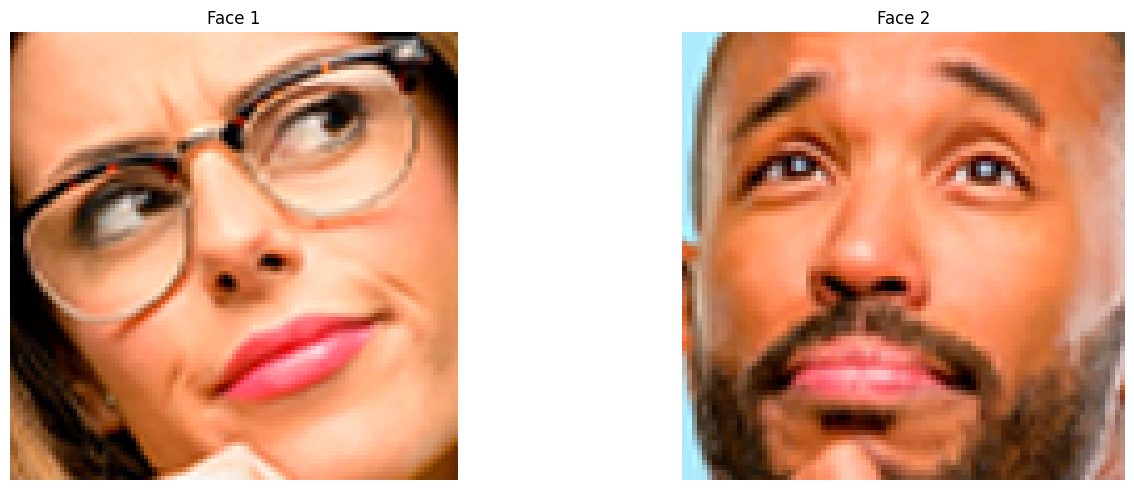

In [99]:
# Coordinate conversion (rect_to_bb): We write a small helper function. dlib returns coordinates in the form (left_edge, top, right_edge, bottom). The cv2.rectangle function often uses the (x, y, width, height) format for drawing, where (x, y) are the coordinates of the upper-left corner. This function simply performs the necessary conversion.

def rect_to_bb(rect):

    x = rect.left()
    y = rect.top()
    w = rect.right() - x
    h = rect.bottom() - y
    return (x, y, w, h)

result = np.copy(img_rgb)

# List of colors
colors = [
    (255, 0, 0),      # Red
    (0, 255, 0),      # Green
    (0, 0, 255),      # Blue
    (255, 255, 0),    # Yellow
    (255, 0, 255),    # Purple
    (0, 255, 255),    # Cyan
    (255, 128, 0),    # Orange
    (128, 0, 255),    # Violet
]

# Array for finding faces
faces_img = []

# Looping through detected faces: We loop through all the rectangles found by the detector.
#
# Drawing: For each face, we:
#
# Select a color: colors[i % len(colors)] — this is an elegant way to loop through a predefined list of colors so that each face has a frame of its own color. The % (modulo) operator ensures that we don't exceed the end of the list.
#
# Draw a rectangle (cv2.rectangle): We draw a rectangle with the desired coordinates, color, and line width on a copy of the original color image.
#
# Add text (cv2.putText): We label each face so that it's clear which number it is.
#
# Crop a face: Using NumPy slices img_rgb[y:y+h, x:x+w], we "crop" the region containing the face from the image and save it. This is very useful for subsequent steps, such as a face recognition system.
for i, rect in enumerate(rects):

    x, y, w, h = rect_to_bb(rect)
    color = colors[i % len(colors)]
    cv2.rectangle(result, (x, y), (x+w, y+h), color, 3)
    cv2.putText(result, f'Face {i+1}', (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
    faces_img.append(img_rgb[y:y+h, x:x+w, :])


plt.figure(figsize=(15, 10))
plt.imshow(result)
plt.title(f'Detected Faces: {len(rects)}')
plt.axis('off')
plt.show()


if len(faces_img) > 0:
    n_faces = len(faces_img)
    cols = min(4, n_faces)
    rows = (n_faces + cols - 1) // cols

    plt.figure(figsize=(15, 5 * rows))
    for i, face in enumerate(faces_img):
        plt.subplot(rows, cols, i+1)
        plt.imshow(face)
        plt.title(f'Face {i+1}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

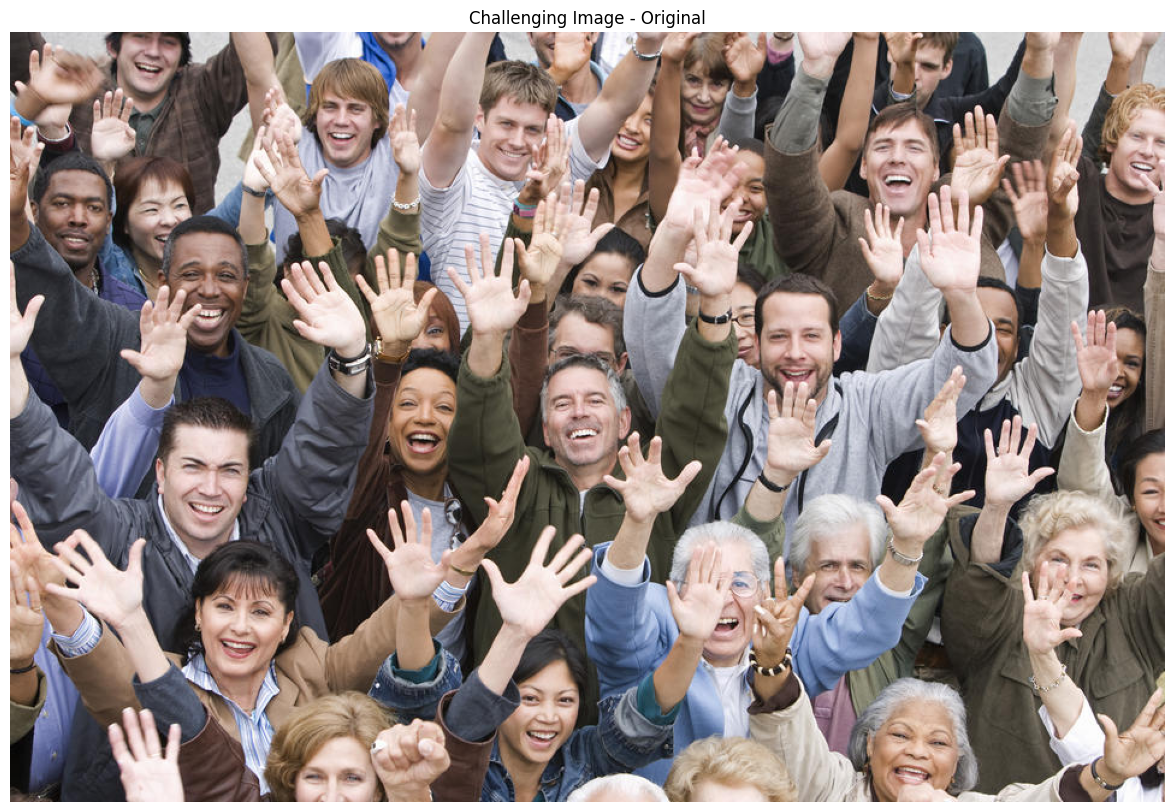

Testing with upsampling = 2...
Faces detected: 18

Testing with upsampling = 1...
Faces detected: 20

Selecting result from upsampling=1 (more faces found).


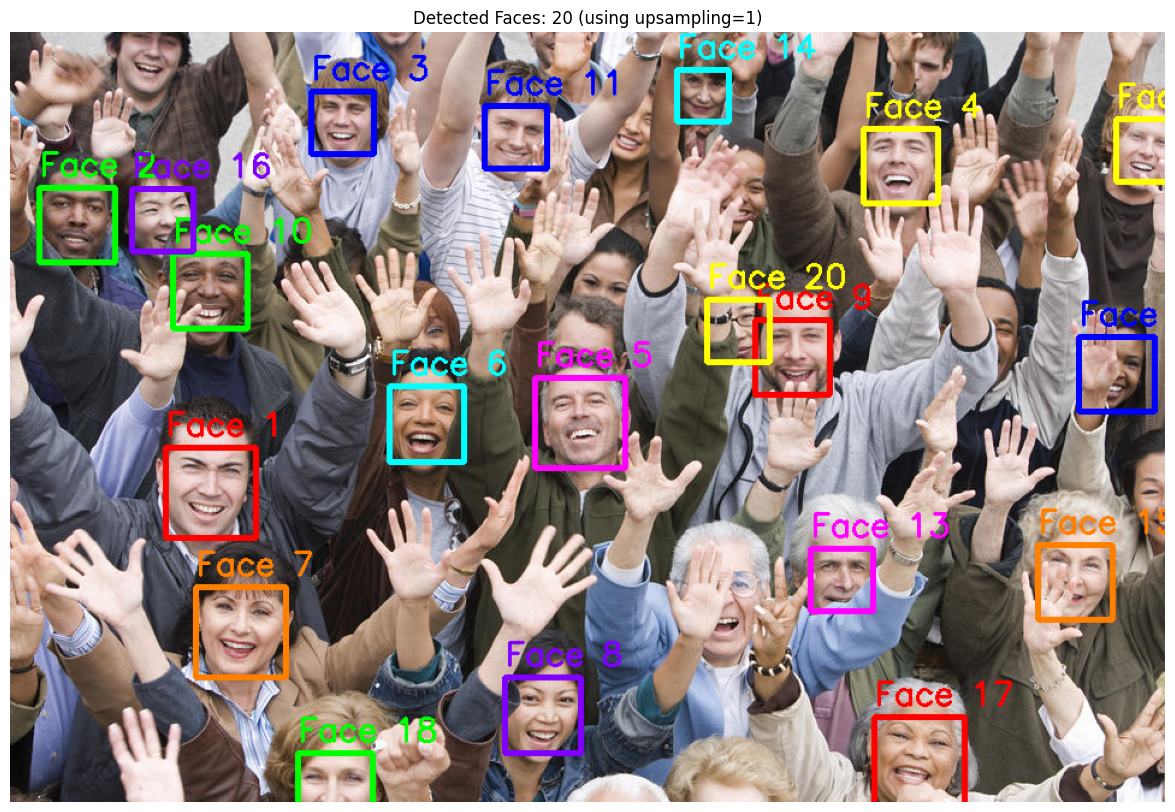

In [100]:
# Load image with many people
img2 = cv2.imread('../data/crowdofpeople.jpg')

if img2 is not None:
    # --- Configuration for Upsampling ---
    # Change these two values to test different upsampling parameters.
    upsample_val_1 = 2  # Corresponds to your uns1
    upsample_val_2 = 1  # Corresponds to your uns2
    # ------------------------------------

    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    plt.figure()
    plt.imshow(img2_rgb)
    plt.title('Challenging Image - Original')
    plt.axis('off')
    plt.show()

    # Apply the detector using the variables defined above
    print(f"Testing with upsampling = {upsample_val_1}...")
    results_1 = detector(gray2, upsample_val_1)
    print(f"Faces detected: {len(results_1)}")

    print(f"\nTesting with upsampling = {upsample_val_2}...")
    results_2 = detector(gray2, upsample_val_2)
    print(f"Faces detected: {len(results_2)}")

    # Automatically choose the result with more faces
    if len(results_1) >= len(results_2):
        print(f"\nSelecting result from upsampling={upsample_val_1} (more faces found).")
        rects2 = results_1
        chosen_upsample_val = upsample_val_1
    else:
        print(f"\nSelecting result from upsampling={upsample_val_2} (more faces found).")
        rects2 = results_2
        chosen_upsample_val = upsample_val_2

    result2 = np.copy(img2_rgb)

    # Loop over the detected faces and draw rectangles
    for i, rect in enumerate(rects2):
        x, y, w, h = rect_to_bb(rect)
        color = colors[i % len(colors)]
        cv2.rectangle(result2, (x, y), (x + w, y + h), color, 3)
        cv2.putText(result2, f'Face {i + 1}', (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    # Display the final result
    plt.figure(figsize=(15, 10))
    plt.imshow(result2)
    plt.title(f'Detected Faces: {len(rects2)} (using upsampling={chosen_upsample_val})')
    plt.axis('off')
    plt.show()

else:
    print("Challenging image not loaded. Skipping this step.")




### Note
I've noticed that even with different unsampling values, it doesn't always find the same faces. For example, with value 1, I find faces that aren't visible with values ​​2 or 3.